# Topología de Redes

## Análisis de una red de interacción de proteínas mediante NetworkX.
**Cargar el grafo del CaernoElegans-LC_uw.txt, que contiene una red de interacción de proteínas correspondiente al gusano Caernobidis Elegans en formato lista de ramas:**

In [2]:
G_CE = nx.read_edgelist("CaernoElegans-LC_uw.txt")


**Obtener e imprimir por la salida el orden y el tamaño del grafo y averiguad si el grafo es dirigido o no. ¿Es un grafo denso o disperso?**

In [4]:
orden = nx.number_of_nodes(G_CE)
print("El orden es:", orden)

tam = nx.number_of_edges(G_CE)
print("El tamaño es:", tam)

dir = nx.is_directed(G_CE)
print("¿Dirigido?:", dir)

densidad = nx.density(G_CE)
print("La densidad es:", densidad*100,"%")

El orden es: 1387
El tamaño es: 1648
¿Dirigido?: False
La densidad es: 0.1714539566017576 %


Vemos que no es dirigido y la densidad es ~ 0.17%.

Un grafo denso tiene una densidad cercana a 1 (muchas aristas comparadas con el máximo posible). Un grafo disperso la tiene cercana a 0 (pocas aristas). En este caso, la densidad es extremadamente baja, lo que indica que el grafo es **disperso**.

**Crear un grafo aleatorio G_AL que tenga el mismo orden y tamaño que el grafo que acabáis de cargar mediante la función gnm_random_graph(n,m)**

**Indicar si ambos grafos son conexos.**

In [38]:
print(nx.is_connected(G_CE))
print(nx.is_connected(G_AL))

False
False


Ninguno de los dos es conexo, lo que significa que existe al menos un par de nodos del grafo para los que no hay camino de union.

**¿Cuál es el nodo con mayor grado en cada grafo?**

In [44]:
print("G_CE:", max(G_CE.degree(), key=lambda x: x[1]))
print("G_AL:", max(G_AL.degree(), key=lambda x: x[1]))

G_CE: ('T08G11.5', 131)
G_AL: (152, 8)


- Vemos que en el grafo del **Caernobidis** el nodo de mayor grado es el 'T08G11.5' con grado 131, lo que sugiere que es un "hub" (nodo altamente conectado).
- Por otro lado en el **grafo aleatorio** es el nodo 152 con grado 8. En grafos aleatorios los grados siguen una distribución de Poisson, donde la mayoría de nodos tienen grados similares y no hay hubs prominentes.

**¿Cuál es la máxima distancia entre dos nodos del grafo (diámetro del grafo)?**

En nuestro caso, como hemos visto anteriormente nuestros grafos no son conexos. Con lo cual el cálculo de diametro = nx.diameter(G_CE) da infinito (porque hay nodos sin camino entre ellos). Con lo cual, al no ser conexo no se puede calcular el diámetro.

## Distribución del grado de los nodos.

**1. Visualizad la distribución del grado de los nodos de ambos grafos.**

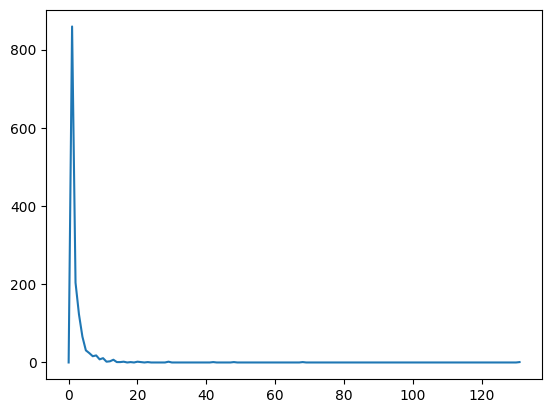

In [10]:
H=nx.degree_histogram(G_CE)
plt.plot(range(len(H)),H)
plt.show()

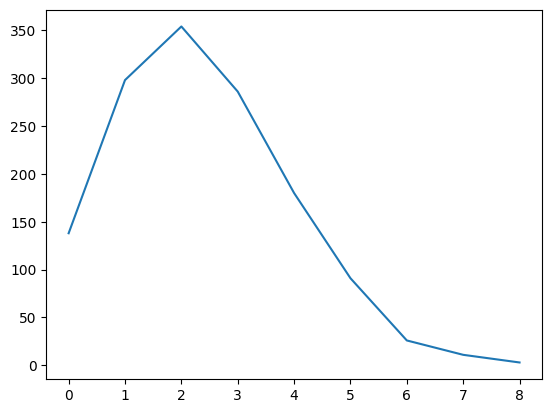

In [11]:
J=nx.degree_histogram(G_AL)
plt.plot(range(len(J)), J)
plt.show()

**2. ¿Son iguales las gráficas de distribución de grados de ambos grafos?, ¿Qué conclusión sacas de lo anterior?**

Vemos que la forma de la distribución no se parece, por tanto se deduce que la red de *C. elegans* no es aleatoria.

**3. Dibuja ahora la distribución del grado de los nodos de la red de interacción de proteínas usando escala logarítmica en ambos ejes, añade para ello estas dos líneas de código para cambiar el tipo de escala en cada eje
plt.xscale("log", nonposx='clip') plt.yscale("log", nonposy='clip')**

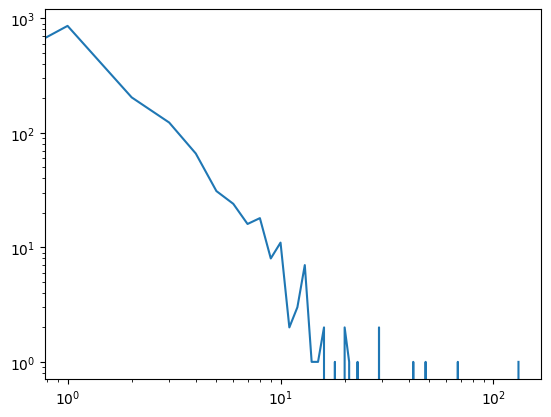

In [7]:
H=nx.degree_histogram(G_CE)
plt.plot(range(len(H)),H)
plt.xscale("log", nonpositive='clip') 
plt.yscale("log", nonpositive='clip')

**4. ¿Qué tipo de gráfica obtienes? ¿Podrías calcular aproximadamente la pendiente de los datos?**

Podemos ver que al usar escala logarítmica, obtenemos una función decreciente que se asimila a una recta, sobre todo al principio. 

In [ ]:
# Obtener el histograma de grados
H = nx.degree_histogram(G_CE)
x = np.arange(len(H))  # Eje X: grados (k)
y = np.array(H)        # Eje Y: frecuencia (P(k))

# Filtrar valores mayores que cero (log(0) no existe)
mask = (y > 0) & (x > 0)  # Ignorar k=0 y P(k)=0
x_filtered = x[mask]
y_filtered = y[mask]

# Aplicar logaritmo a ambos ejes
log_x = np.log10(x_filtered)
log_y = np.log10(y_filtered)

# Ajustar una recta (grado 1) por mínimos cuadrados
slope, intercept = np.polyfit(log_x, log_y, 1)

print(f"Pendiente (γ) ≈ {slope:.3f}")

Pendiente (γ) ≈ -1.622


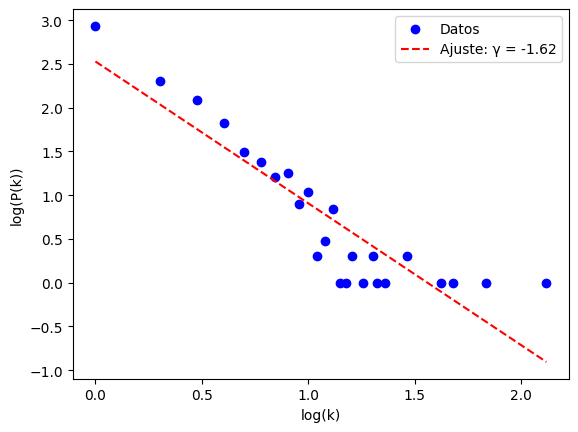

In [18]:
plt.scatter(log_x, log_y, color='blue', label='Datos')
plt.plot(log_x, slope * log_x + intercept, 'r--', label=f'Ajuste: γ = {slope:.2f}')
plt.xlabel("log(k)")
plt.ylabel("log(P(k))")
plt.legend()
plt.show()

## Cálculo de parámetros de los grafos.
**1. Calculad, al menos, los siguientes parámetros para ambos grafos**

- Centralidad de grado

In [36]:
d = nx.degree_centrality(G_CE)
ds = sum(d.values())/orden
print(f'La centralidad de grado de C. elegans es: {ds}')

d_rnd = nx.degree_centrality(G_AL)
ds_rnd = sum(d_rnd.values())/orden
print(f'La centralidad de grado del grafo aleatorio es: {ds_rnd}')

La centralidad de grado de C. elegans es: 0.0017145395660175763
La centralidad de grado del grafo aleatorio es: 0.0017145395660175763


- Closeness

In [37]:
c = nx.closeness_centrality(G_CE)
cs = sum(c.values())/orden
print(f'El closeness de C elegans es: {cs}')

c_rnd = nx.closeness_centrality(G_CE)
cs_rnd = sum(c_rnd.values())/orden
print(f'El closeness del grafo aleatorio es: {cs_rnd}')

El closeness de C elegans es: 0.0711426803353807
El closeness del grafo aleatorio es: 0.0711426803353807


- Betweenness

In [38]:
b = nx.betweenness_centrality(G_CE)
bs = sum(b.values())/orden
print(f'EL betweenness de C. elegans es: {bs}')

b_rnd = nx.betweenness_centrality(G_CE)
bs_rnd = sum(b.values())/orden
print(f'EL betweenness del grafo aleatorio es: {bs_rnd}')

EL betweenness de C. elegans es: 0.0025678228687606645
EL betweenness del grafo aleatorio es: 0.0025678228687606645


Estos parámetros vemos que coinciden exactamente entre el grafo aleatorio y el de *C. elegans*, lo que es resultado de que ambos tengan el mismo número de nodos y ramas. Sin embargo, vemos que a partir de ahora ya existen diferencias claras. 

- Índice de clusterización (C)

In [39]:
a = nx.average_clustering(G_CE)
print(f' El índice de clusterización (C) de C.elegans es: {a}')

a_rnd = nx.average_clustering(G_AL)
print(f' El índice de clusterización (C) del grafo aleatorio es: {a_rnd}')

 El índice de clusterización (C) de C.elegans es: 0.07570841434149082
 El índice de clusterización (C) del grafo aleatorio es: 0.0004869479635160961


- Máximo k para el cual existe un k core

In [ ]:
core = nx.core_number(G_CE)
print(f' El core_number de C.elegans es: {max(core.values())}')

core_rnd = nx.core_number(G_AL)
print(f' El core_number del grafo aleatorio es: {max(core_rnd.values())}')

 El core_number de C.elegans es: 6
 El core_number del grafo aleatorio es: 2


Para posterior uso, calculamos también el camino característico de ambos grafos (L). Dado que la red de C.elegans no es conexa, no se puede calcular L de forma directa, pero sí se puede calcular L de la componente conexta con mayor grado. Lo mismo podemos hacer con el grafo aleatorio. 

A pesar de no ser tan exacto, puede tratarse de una aproximación adecuada para hacerse una idea.

In [ ]:
# Extraemos la componente conexa con mayor grado
GCC = max(nx.connected_components(G_CE), key=len)

# Sacamos esa componente como un subgrafo de G_CE
G_gcc = G_CE.subgraph(GCC)

# Calculamos L en el subgrafo 
l = nx.average_shortest_path_length(G_gcc)
print(f'El camino característico (L) de C.elegans es: {l}')

# Hacemos lo mismo para el grafo aleatorio
GCC_rnd = max(nx.connected_components(G_AL), key=len)
G_gcc_rnd = G_AL.subgraph(GCC_rnd)

l_rnd = nx.average_shortest_path_length(G_gcc_rnd)
print(f'El camino característico (L) del grafo aleatorio es: {l_rnd}')

El camino característico (L) de C.elegans es: 7.922564808498197
El camino característico (L) del grafo aleatorio es: 8.121644638279456


## Gráfos Aleatorios, Regulares, de Mundo pequeño y libres de escala 

### Estudiar las propiedades de un grafo aleatorio

- Usando la función gnp_random_graph(n,p) de NetworkX Implementad una rutina Python L_C_Aleatorio que devuelva valor promedio de los coeficientes C (índice de clusterización promedio) y L (camino característico) de un conjunto de n_graph grafos aleatorios de n nodos y probabilidad p.


In [ ]:
def  L_C_Aleatorio(n_graph,n,p):
    
    # Listas vacías para guardar los valores de C y L de cada grafo
    C_values = []
    L_values = []

    # Creamos los grafos y calculamos C y L
    for _ in range(n_graph):
        g = nx.gnp_random_graph(n, p) # crear grafo
        c = nx.average_clustering(g) # calcular C
        C_values.append(c)
        
        # Cáluclo de L
        if nx.is_connected(g):
            l = nx.average_shortest_path_length(g)
            L_values.append(l)
        # Si el grafo no es conexo, usar n-1
        else:
            L_values.append(n-1)
    
    return np.mean(C_values), np.mean(L_values)


In [ ]:
n = 400
n_graph = 20
p_values = [0, 0.0001, 0.0003, 0.0006, 0.001, 0.003, 0.006, 0.01, 0.03, 0.06, 0.1, 0.3, 0.6, 1.]

# Listas vacías para guardar valores de C y L para cada valor de p
L_of_p = []
C_of_p = []

for p in p_values:
    c, l = L_C_Aleatorio(n_graph, n, p)
    C_of_p.append(c)
    L_of_p.append(l)


- Usando la rutina anterior, dibujar el comportamiento de L, C para distintos valores de la
    probabilidad p y un número fijo de nodos. 

    Tomar n=400, n_graph=20 y los siguientes valores de p

    [0, 0.0001, 0.0003, 0.0006, 0.001, 0.003, 0.006, 0.01, 0.03, 0.06, 0.1, 0.3, 0.6, 1.]

    Dibujad una gráfica que describa el comportamiento de estos dos parámetros como función de p, usad escala logarítmica en el eje x. ¿Para qué probabilidades p se producen cambios fase en el comportamiento los parámetros L, C? 

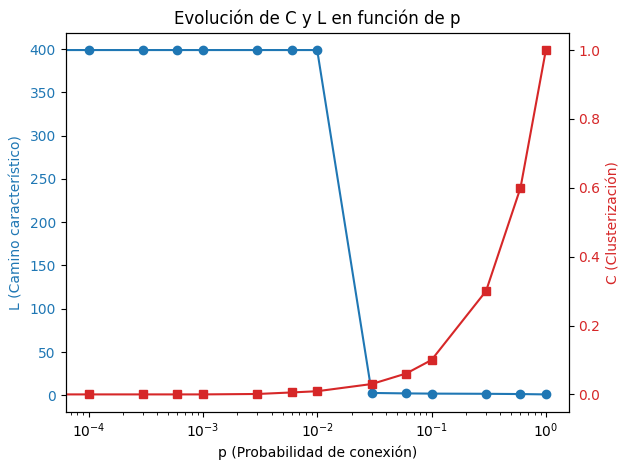

In [28]:
fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel('p (Probabilidad de conexión)')
ax1.set_ylabel('L (Camino característico)', color=color)
ax1.semilogx(p_values, L_of_p, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # segundo eje y
color = 'tab:red'
ax2.set_ylabel('C (Clusterización)', color=color)
ax2.semilogx(p_values, C_of_p, marker='s', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evolución de C y L en función de p')
plt.tight_layout()
plt.show()

**¿Para qué probabilidades p se producen cambios fase en el comportamiento los parámetros L, C?** 

Podemos observar que el comportamiento de C aumenta según aumenta p, lo que es de esperar. En grafos aleatorios, C ≈ p, por tanto, para valores bajos de p, C es prácticamente 0, pero cuando p = 1, C = 1. 

También vemos un cambio claro en L. De forma teórica, cuando $p < \frac{Ln(N)}{N}$ los grafos son disconexos y por tanto L >> 1 (más en concreto L ≈ N), pero cuando se llega al umbral $c_p = \frac{Ln(N)}{N}$ (en este caso $1.5 \times 10^{-2}$), pasa a formarse una componente gigante y el grafo se vuelve mucho más conectado, lo que hace que L baje drásticamente.

### Redes regulares y de mundo pequeño

- Usando la función de NetworkX watts_strogatz_graph(n, k, p) implementad una rutina Python L_C_small_world(n_graph, n,k,p) que devuelva valor promedio de los coeficientes C (índice de clusterización promedio) y L (camino característico) para un conjunto de n_graph grafos de tipo Small World

In [22]:
def  L_C_Small_World(n_graph, n, k, p):
    
    C_values = []
    L_values = []

    for _ in range(n_graph):
        g = nx.watts_strogatz_graph(n, k, p)
        c = nx.average_clustering(g)
        C_values.append(c)
        
        if nx.is_connected(g):
            l = nx.average_shortest_path_length(g)
            L_values.append(l)
        else:
            L_values.append(n-1)
    
    return np.mean(C_values), np.mean(L_values)

- Usando la rutina anterior, generar una gráfica con el comportamiento de C y L para distintos valores de la probabilidad p y un número fijo de nodos y ramas. 

    Tomar N=400, k=8 y los siguientes valores de p:

    [0, 0.0001, 0.0003, 0.0006, 0.001, 0.003, 0.006, 0.01, 0.03, 0.06, 0.1, 0.3, 0.6, 1.]

In [23]:
# n = 400
k=8
# n_graph = 20
#p_values = [0, 0.0001, 0.0003, 0.0006, 0.001, 0.003, 0.006, 0.01, 0.03, 0.06, 0.1, 0.3, 0.6, 1.]

L_of_p_2 = []
C_of_p_2 = []

for p in p_values:
    c, l = L_C_Small_World(n_graph, n, k, p)
    C_of_p_2.append(c)
    L_of_p_2.append(l)

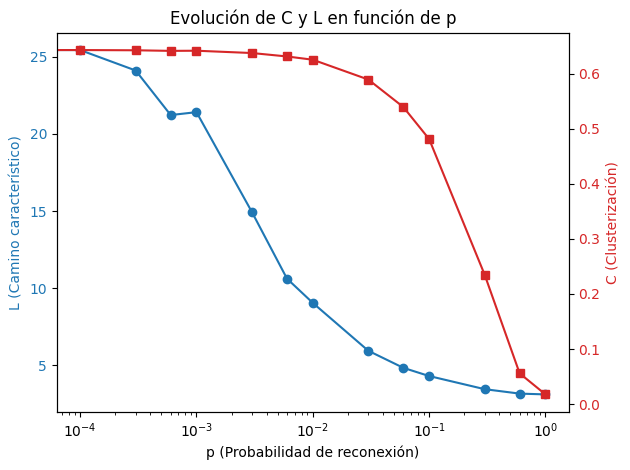

In [27]:
fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel('p (Probabilidad de reconexión)')
ax1.set_ylabel('L (Camino característico)', color=color)
ax1.semilogx(p_values, L_of_p_2, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # segundo eje y
color = 'tab:red'
ax2.set_ylabel('C (Clusterización)', color=color)
ax2.semilogx(p_values, C_of_p_2, marker='s', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evolución de C y L en función de p')
plt.tight_layout()
plt.show()


**¿Para qué probabilidades p se producen cambios fase en el comportamiento los parámetros L y C? ¿Entre que valores de p dirías que está la zona de Small-World para estos valores de N y k. ¿Corresponde el valor de p observado con el valor de p teórico para el cambio de fase en el comportamiento del camino característico? Comparar las gráficas obtenidas de C y L con las correspondientes gráficas teóricas.**

Vemos claramente la relación común de mundo pequeño. Vemos que C, con p bajo, al no haber reconexiones, tiene el valor común de grafos regulares (0.75), pero según se va aumentando p (es decir, la probabilidad de reconexión entre nodos), se pasa a un comportamiento de grafo aleatorio con C bajo. 

En el caso de L, se ve un comportamiento similar al del grafo aleatorio, ya que según aumenta p, disminuye L. De esta forma, podemos establecer una región de mundo pequeño en la cual C es grande, pero L es pequeño. Un rango aproximado sería entre $10^{-2}$ y $1.5 \times 10^{-2}$, donde C empieza a caer lentamente, pero L ya ha bajado de forma considerable.

**Con los datos que obtuviste en la práctica 1. ¿Dirías que la red de interacción de proteínas del Caernobidis Elegans puede ser considerada una red de mundo pequeño (Razona la respuesta)?** 

Para comprobarlo, basta con comparar los valores de L y C de la red de *C.elegans* con el respectivo grafo aleatorio de igual grado y tamaño (valores calculados en el apartado 4 de la parte 1).

En el caso de C tenemos: 

- C de *C.elegans*: 0.0757
- C del grafo aleatorio correspondiente: 0.00049. 

Vemos que C es mucho mayor en el grafo de *C.elegans* que en su grafo aleatorio, lo cual concuerda con la teoría de grafo de mundo pequeño: un valor de C alto en comparación con un grafo aleatorio de igual grado y tamaño.

Con respecto a L, calculado también anteriormente (aunque con la componente conexa de mayor grado), tenemos lo siguiente: 

- L de *C.elegans*: 7.92
- L del grafo aleatorio correspondiente: 8.12

Vemos que en este caso, los valores de L son muy similares, lo cual confirma que la red de *C.elegans* es de mundo pequeño, ya que también tiene un valor de L similar al de su grafo aleatorio. 

### Redes libres de Escala

- Generar una red libre de escala con 10000 nodos y que añade 10 nodos en cada paso (utilizad la rutina barabasi_albert_graph(n, m)). 

- Calculad los valores de L, C y la distribución de grado de los nodos.

El camino característico (L) de la red libre de escala es: 2.5604924924924926
El índice de clusterización (C) de la red libre de escala es: 0.05910572265685702


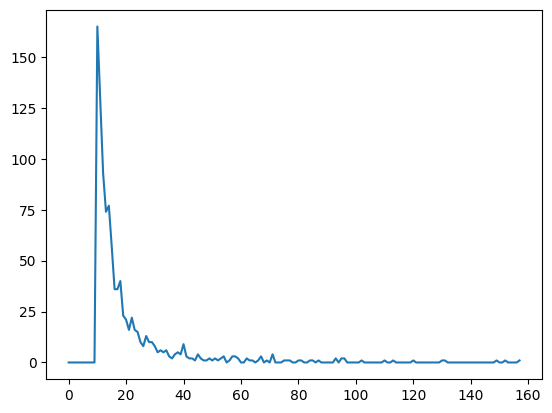

In [5]:
# Generamos la red libre de escala
G_Libre = nx.barabasi_albert_graph(1000, 10, seed=8)

# Calculamos L
L_libre = nx.average_shortest_path_length(G_Libre)
print(f'El camino característico (L) de la red libre de escala es: {L_libre}')

# Calculamos C
C_libre = nx.average_clustering(G_Libre)
print(f'El índice de clusterización (C) de la red libre de escala es: {C_libre}')

# Distribución del grado de los nodos
GN_Libre = nx.degree_histogram(G_Libre)
plt.plot(range(len(GN_Libre)),GN_Libre)
plt.show()

- Generad una red aleatoria que tenga el mismo número de nodos y ramas que la red que habéis creado, calculad sus valores de L, C y la distribución del grado de los nodos y comparad los valores obtenidos. 

In [7]:
# Obtenemos ciertos parametros del grafo
ordenL = nx.number_of_nodes(G_Libre)
print("El orden del grafo libre de escala es:", ordenL)

tamL = nx.number_of_edges(G_Libre)
print("El tamaño del grafo libre de escala es:", tamL)

# Creamos el grafo aleatorio con el mismo numero de nodos y ramas:
G_Libre_AL = nx.gnm_random_graph(ordenL,tamL)
print("\nLa red aleatoria a partir éste es la siguiente:")
print(G_Libre_AL)

El orden del grafo libre de escala es: 1000
El tamaño del grafo libre de escala es: 9900

La red aleatoria a partir éste es la siguiente:
Graph with 1000 nodes and 9900 edges


El camino característico (L) del grafo aleatorio es: 2.644854854854855
El índice de clusterización (C) del grafo aleatorio es: 0.020087347726557556


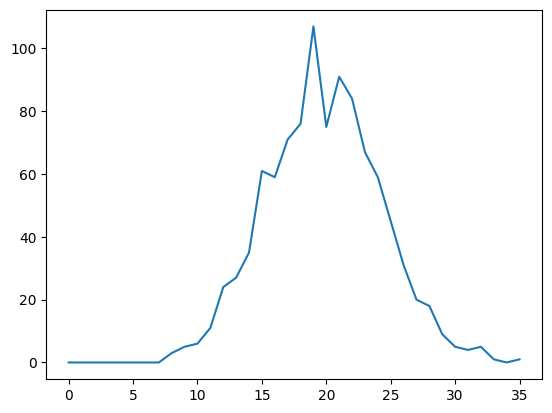

In [8]:
# Calculamos L
L_AL = nx.average_shortest_path_length(G_Libre_AL)
print(f'El camino característico (L) del grafo aleatorio es: {L_AL}')

# Calculamos C
C_AL = nx.average_clustering(G_Libre_AL)
print(f'El índice de clusterización (C) del grafo aleatorio es: {C_AL}')

# Distribución del grado de los nodos
GN_AL = nx.degree_histogram(G_Libre_AL)
plt.plot(range(len(GN_AL)),GN_AL)
plt.show()

Vamos a ver la distribución de grados de ambas redes en escala log-log:

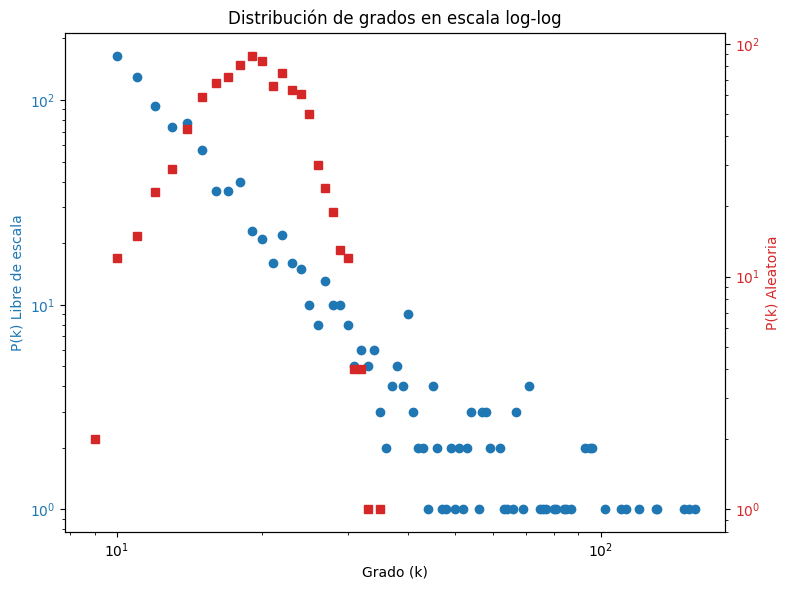

In [23]:
# Función para obtener grados y sus frecuencias
def get_degree_distribution(graph):
    degrees = [d for n, d in graph.degree()]
    degree_counts = np.bincount(degrees)
    k_vals = np.nonzero(degree_counts)[0]
    freq_vals = degree_counts[k_vals]
    return k_vals, freq_vals

# Obtener distribuciones
k_Libre, freq_Libre = get_degree_distribution(G_Libre)
k_AL, freq_AL = get_degree_distribution(G_Libre_AL)

# Crear la figura con dos ejes Y
fig, ax1 = plt.subplots(figsize=(8,6))

color1 = 'tab:blue'
ax1.set_xlabel('Grado (k)')
ax1.set_ylabel('P(k) Libre de escala', color=color1)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.plot(k_Libre, freq_Libre, marker='o', linestyle='', color=color1, label='Libre de escala')
ax1.tick_params(axis='y', labelcolor=color1)

# Segundo eje Y para red aleatoria
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('P(k) Aleatoria', color=color2)
ax2.set_yscale('log')
ax2.plot(k_AL, freq_AL, marker='s', linestyle='', color=color2, label='Aleatoria')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Distribución de grados en escala log-log')
plt.tight_layout()
plt.show()


Los resultados obtenidos muestran lo siguiente:

|             _             | Red libre de escala | Red aleatoria |
| ------------------------- | ------------------- | ------------- |
| Camino característico ($L$) | 2.560               | 2.643         |
| Clustering ($C$)            | 0.059               | 0.020         |

Ambas redes presentan valores bajos y similares de camino característico $L$, lo que indica que las dos poseen la propiedad de pequeño mundo. Sin embargo, la red libre de escala muestra un índice de clustering $C$ ligeramente más alto que la red aleatoria, lo que podría sugerir una mayor tendencia a formar comunidades o agrupaciones locales.

Sin embargo, la diferencia estructural más marcada se observa en la distribución del grado de los nodos. En escala log-log, la red libre de escala sigue una trayectoria aproximadamente lineal decreciente, consistente con una ley de potencias e indicando la presencia de nodos altamente conectados ("hubs"). En cambio, la red aleatoria presenta una distribución con forma de campana (aproximadamente Poisson), donde la mayoría de los nodos tienen grados cercanos al valor medio y los extremos son raros. Esta diferencia evidencia que, pese a compartir L y C bajos, las dos redes tienen topologías profundamente distintas.


## Redes libres de escala y ataques a redes.

### Ataque a una red.

- Implementar una rutina programa ataque_aleatorio(G,m) en Python que realice un ataque aleatorio a m nodos del grafo G.   

In [2]:
def ataque_aleatorio(G,m):
    for i in range(m):
        G.remove_node(list(G.nodes)[random.randint(0,G.number_of_nodes()-1)])

Utilizad la rutina anterior para calcular el tamaño de la mayor componente conexa en grafos aleatorios, de mundo pequeño y libres de escala de 1000 nodos y 4000 ramas tras ataques de 10%, 30%, 50%, 70% y 90% de los nodos del grafo. 

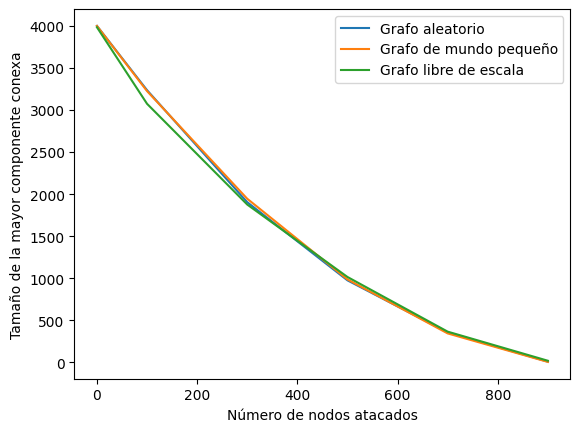

In [ ]:
rn = []
mun_peq = []
lib_esc = []
ataq = [0,100,300,500,700,900]

# Primero lo hacemos para un grafo aleatorio.
for n in ataq:
    H = nx.gnm_random_graph(1000,4000)
    ataque_aleatorio(H,n)

    subgrafo_mas_aristas = max(
    (H.subgraph(c).copy() for c in nx.connected_components(H)),
    key=lambda sg: sg.number_of_edges()
    )

    rn.append(nx.number_of_edges(subgrafo_mas_aristas))

# Después para un grafo de mundo pequeño.
for n in ataq:
    H = nx.watts_strogatz_graph(1000,8,0.5)
    ataque_aleatorio(H,n)

    subgrafo_mas_aristas = max(
    (H.subgraph(c).copy() for c in nx.connected_components(H)),
    key=lambda sg: sg.number_of_edges()
    )

    mun_peq.append(nx.number_of_edges(subgrafo_mas_aristas))

# Por último, un grafo libre de escala.
for n in ataq:
    H = nx.barabasi_albert_graph(1000,4)
    ataque_aleatorio(H,n)

    subgrafo_mas_aristas = max(
    (H.subgraph(c).copy() for c in nx.connected_components(H)),
    key=lambda sg: sg.number_of_edges()
    )

    lib_esc.append(nx.number_of_edges(subgrafo_mas_aristas))

plt.plot(ataq,rn)
plt.plot(ataq,mun_peq)
plt.plot(ataq,lib_esc)
plt.xlabel("Número de nodos atacados")
plt.ylabel("Tamaño de la mayor componente conexa")
plt.legend(["Grafo aleatorio","Grafo de mundo pequeño","Grafo libre de escala"])
plt.show()

- Implementar una rutina programa ataque_grados(G,m) en Python que realice un ataque basado en grados a m nodos del grafo G. 

In [4]:
def ataque_grados(G,m):
    for i in range(m):
        grados = dict(nx.degree(G))
        nodo_max = 0
        for nodo in grados.keys():
            if grados[nodo] == max(grados.values()):
                nodo_max = nodo
        G.remove_node(nodo_max)

Utilizad la rutina anterior para calcular el tamaño de la mayor componente conexa en grafos aleatorios, de mundo pequeño y libres de escala de 1000 nodos y 4000 ramas tras ataques de 10%, 30%, 50%, 70% y 90% de los nodos.  

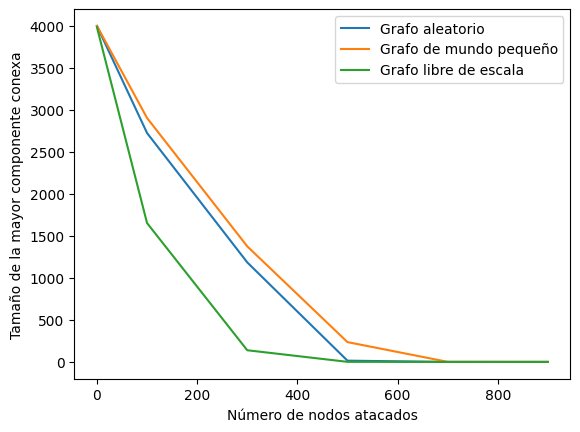

In [ ]:
rn = []
mun_peq = []
lib_esc = []
ataq = [0,100,300,500,700,900]

# Primero, para grafos aleatorios.
for n in ataq:
    H = nx.gnm_random_graph(1000,4000)
    ataque_grados(H,n)

    subgrafo_mas_aristas = max(
    (H.subgraph(c).copy() for c in nx.connected_components(H)),
    key=lambda sg: sg.number_of_edges()
    )

    rn.append(nx.number_of_edges(subgrafo_mas_aristas))

# Después, para grafos de mundo pequeño.
for n in ataq:
    H = nx.watts_strogatz_graph(1000,8,0.5)
    ataque_grados(H,n)

    subgrafo_mas_aristas = max(
    (H.subgraph(c).copy() for c in nx.connected_components(H)),
    key=lambda sg: sg.number_of_edges()
    )

    mun_peq.append(nx.number_of_edges(subgrafo_mas_aristas))

# Por último, para grafos libres de escala.
for n in ataq:
    H = nx.barabasi_albert_graph(1000,4)
    ataque_grados(H,n)

    subgrafo_mas_aristas = max(
    (H.subgraph(c).copy() for c in nx.connected_components(H)),
    key=lambda sg: sg.number_of_edges()
    )

    lib_esc.append(nx.number_of_edges(subgrafo_mas_aristas))

plt.plot(ataq,rn)
plt.plot(ataq,mun_peq)
plt.plot(ataq,lib_esc)
plt.xlabel("Número de nodos atacados")
plt.ylabel("Tamaño de la mayor componente conexa")
plt.legend(["Grafo aleatorio","Grafo de mundo pequeño","Grafo libre de escala"])
plt.show()

- Comparar el resultado obtenido en los dos apartados anteriores. 

En el caso del ataque aleatorio, los tres tipos de grafos (aleatorio, de mundo pequeño y libre de escala) se ven afectados de manera similar, mostrando un descenso gradual en el tamaño de la mayor componente conexa a medida que se eliminan nodos.

En cambio, bajo un ataque dirigido por grado, los tres grafos muestran comportamientos diferentes. En particular, el grafo libre de escala experimenta una rápida caída en el tamaño de su mayor componente conexa, mucho más pronunciada que en los grafos aleatorio y de mundo pequeño. Estos dos últimos muestran una mayor resistencia, aunque el descenso en la conectividad sigue siendo mayor que en el ataque aleatorio.

Esto se debe a que los grafos libres de escala concentran muchas conexiones en pocos nodos de alto grado (hubs), que son cruciales para la conectividad de la red. Al atacar específicamente estos nodos, la red se fragmenta rápidamente. Por el contrario, en los grafos aleatorios y de mundo pequeño, los nodos tienen grados más similares y no existen hubs tan dominantes, lo que hace que la eliminación de los nodos de mayor grado tenga menos impacto relativo.

Además, como el número de hubs en los grafos libres de escala es pequeño, es poco probable que un ataque aleatorio los afecte en las primeras etapas, lo que hace a este tipo de redes altamente resistentes a fallos aleatorios. En cambio, los grafos aleatorio y de mundo pequeño, al no tener nodos especialmente importantes, tienden a ser igualmente resistentes a ambos tipos de ataques, aunque algo más vulnerables al ataque dirigido.